Installing wfdb...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00
CARDIOVISION AI | PTB-XL COMPLETE ECG PIPELINE
Python          : 3.12.13
PyTorch         : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
GPU Memory      : 14.56 GB
AMP Enabled     : True

WFDB FILE VALIDATION
Header files      : 21,837
MAT files         : 21,837
Matched records   : 21,837
Missing MAT       : 0
Missing headers   : 0

OFFICIAL PTB-XL METADATA
Official ptbxl_database.csv not found locally.

Downloading:
https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv
To writable location:
/kaggle/working/cardioVision_PTBXL_COMPLETE/metadata/ptbxl_database.csv
Downloaded: 6.29 MB
Official scp_statements.csv not found locally.

Downloading:
https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv
To writable location:
/kaggle/working/cardioVision_PTBXL_COMPLETE/metadata/scp_statements.csv
Downloaded: 0.01 MB

Metadata records : 21,799
SCP statements   : 71

ROBU

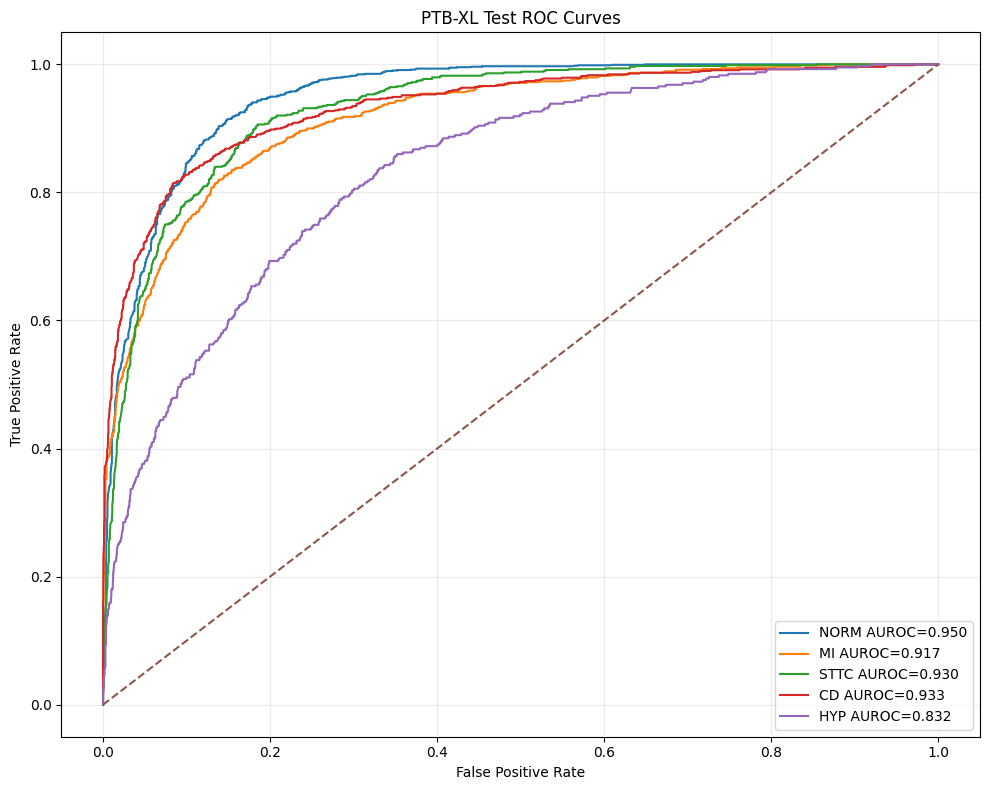

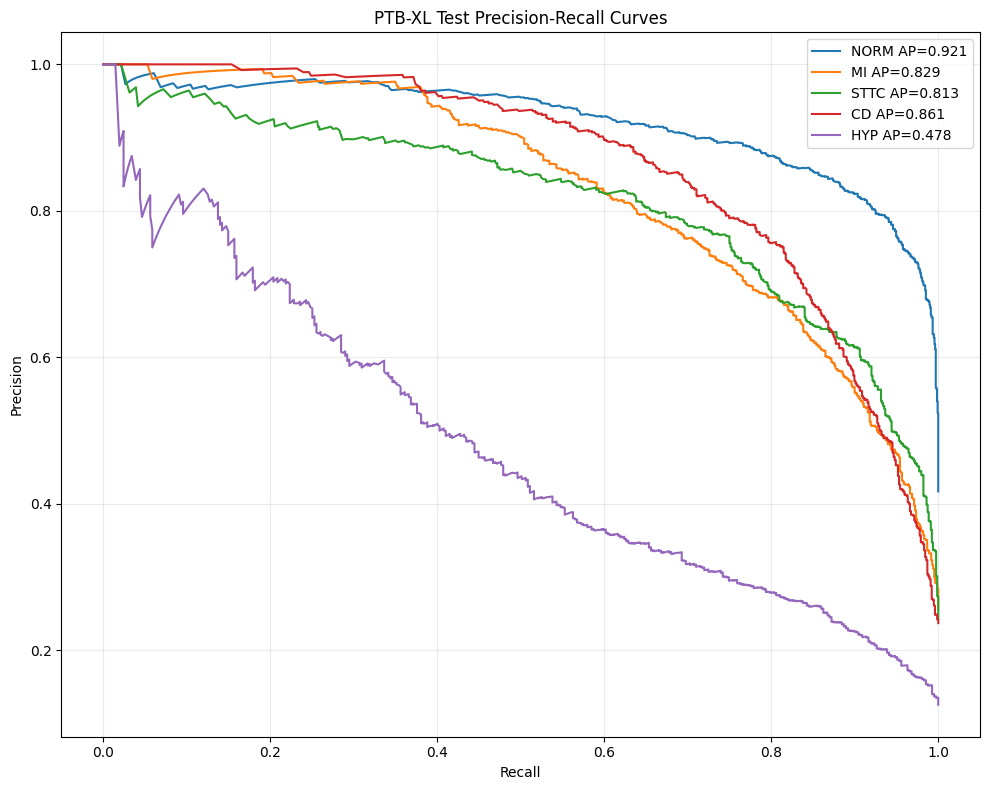

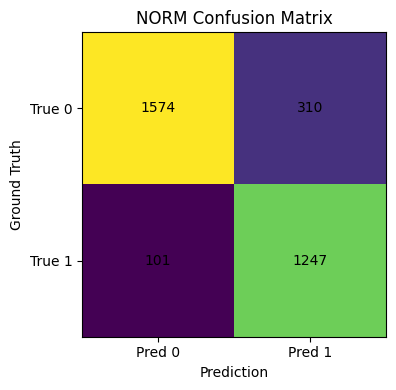

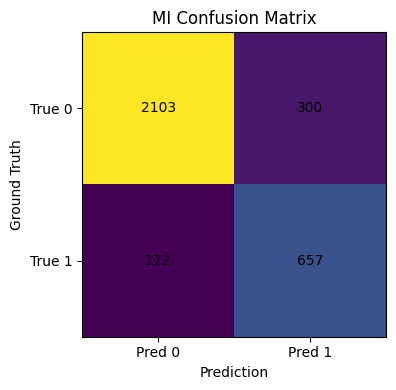

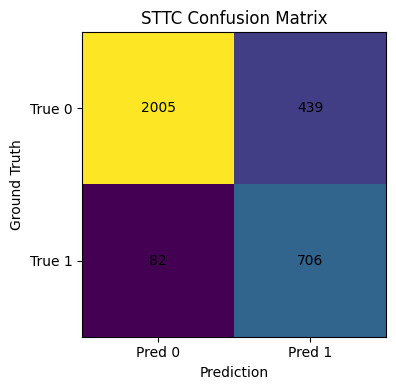

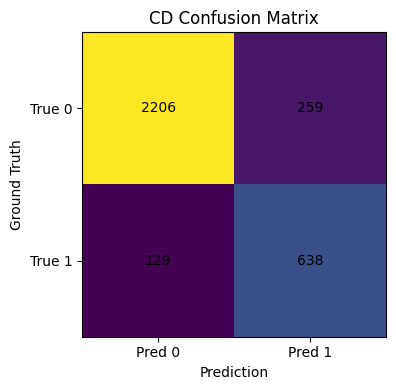

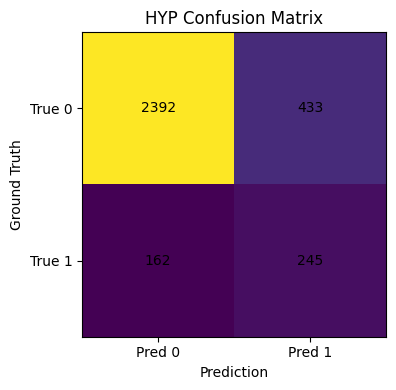

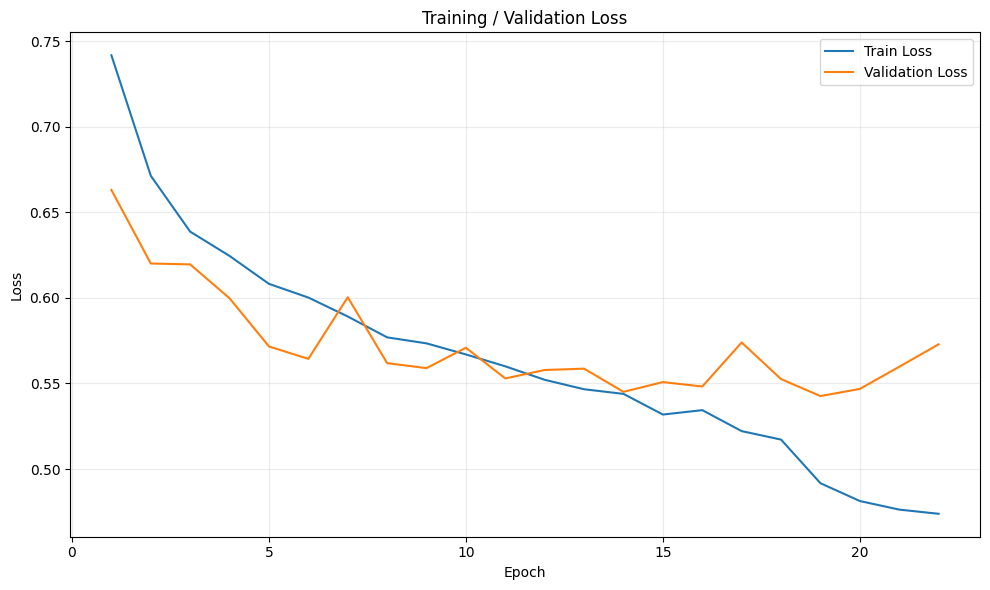

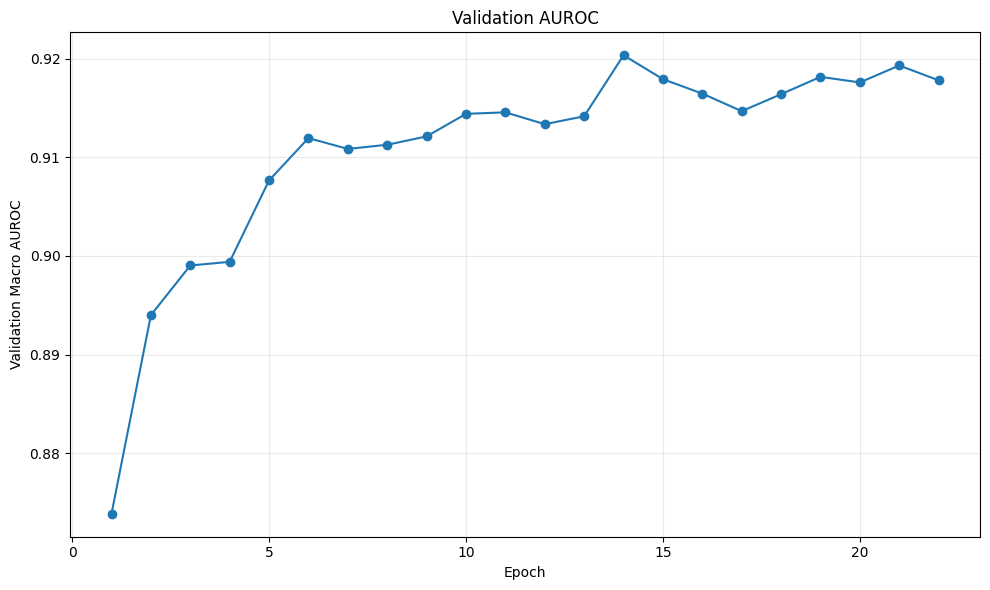


ECG EXPLAINABILITY


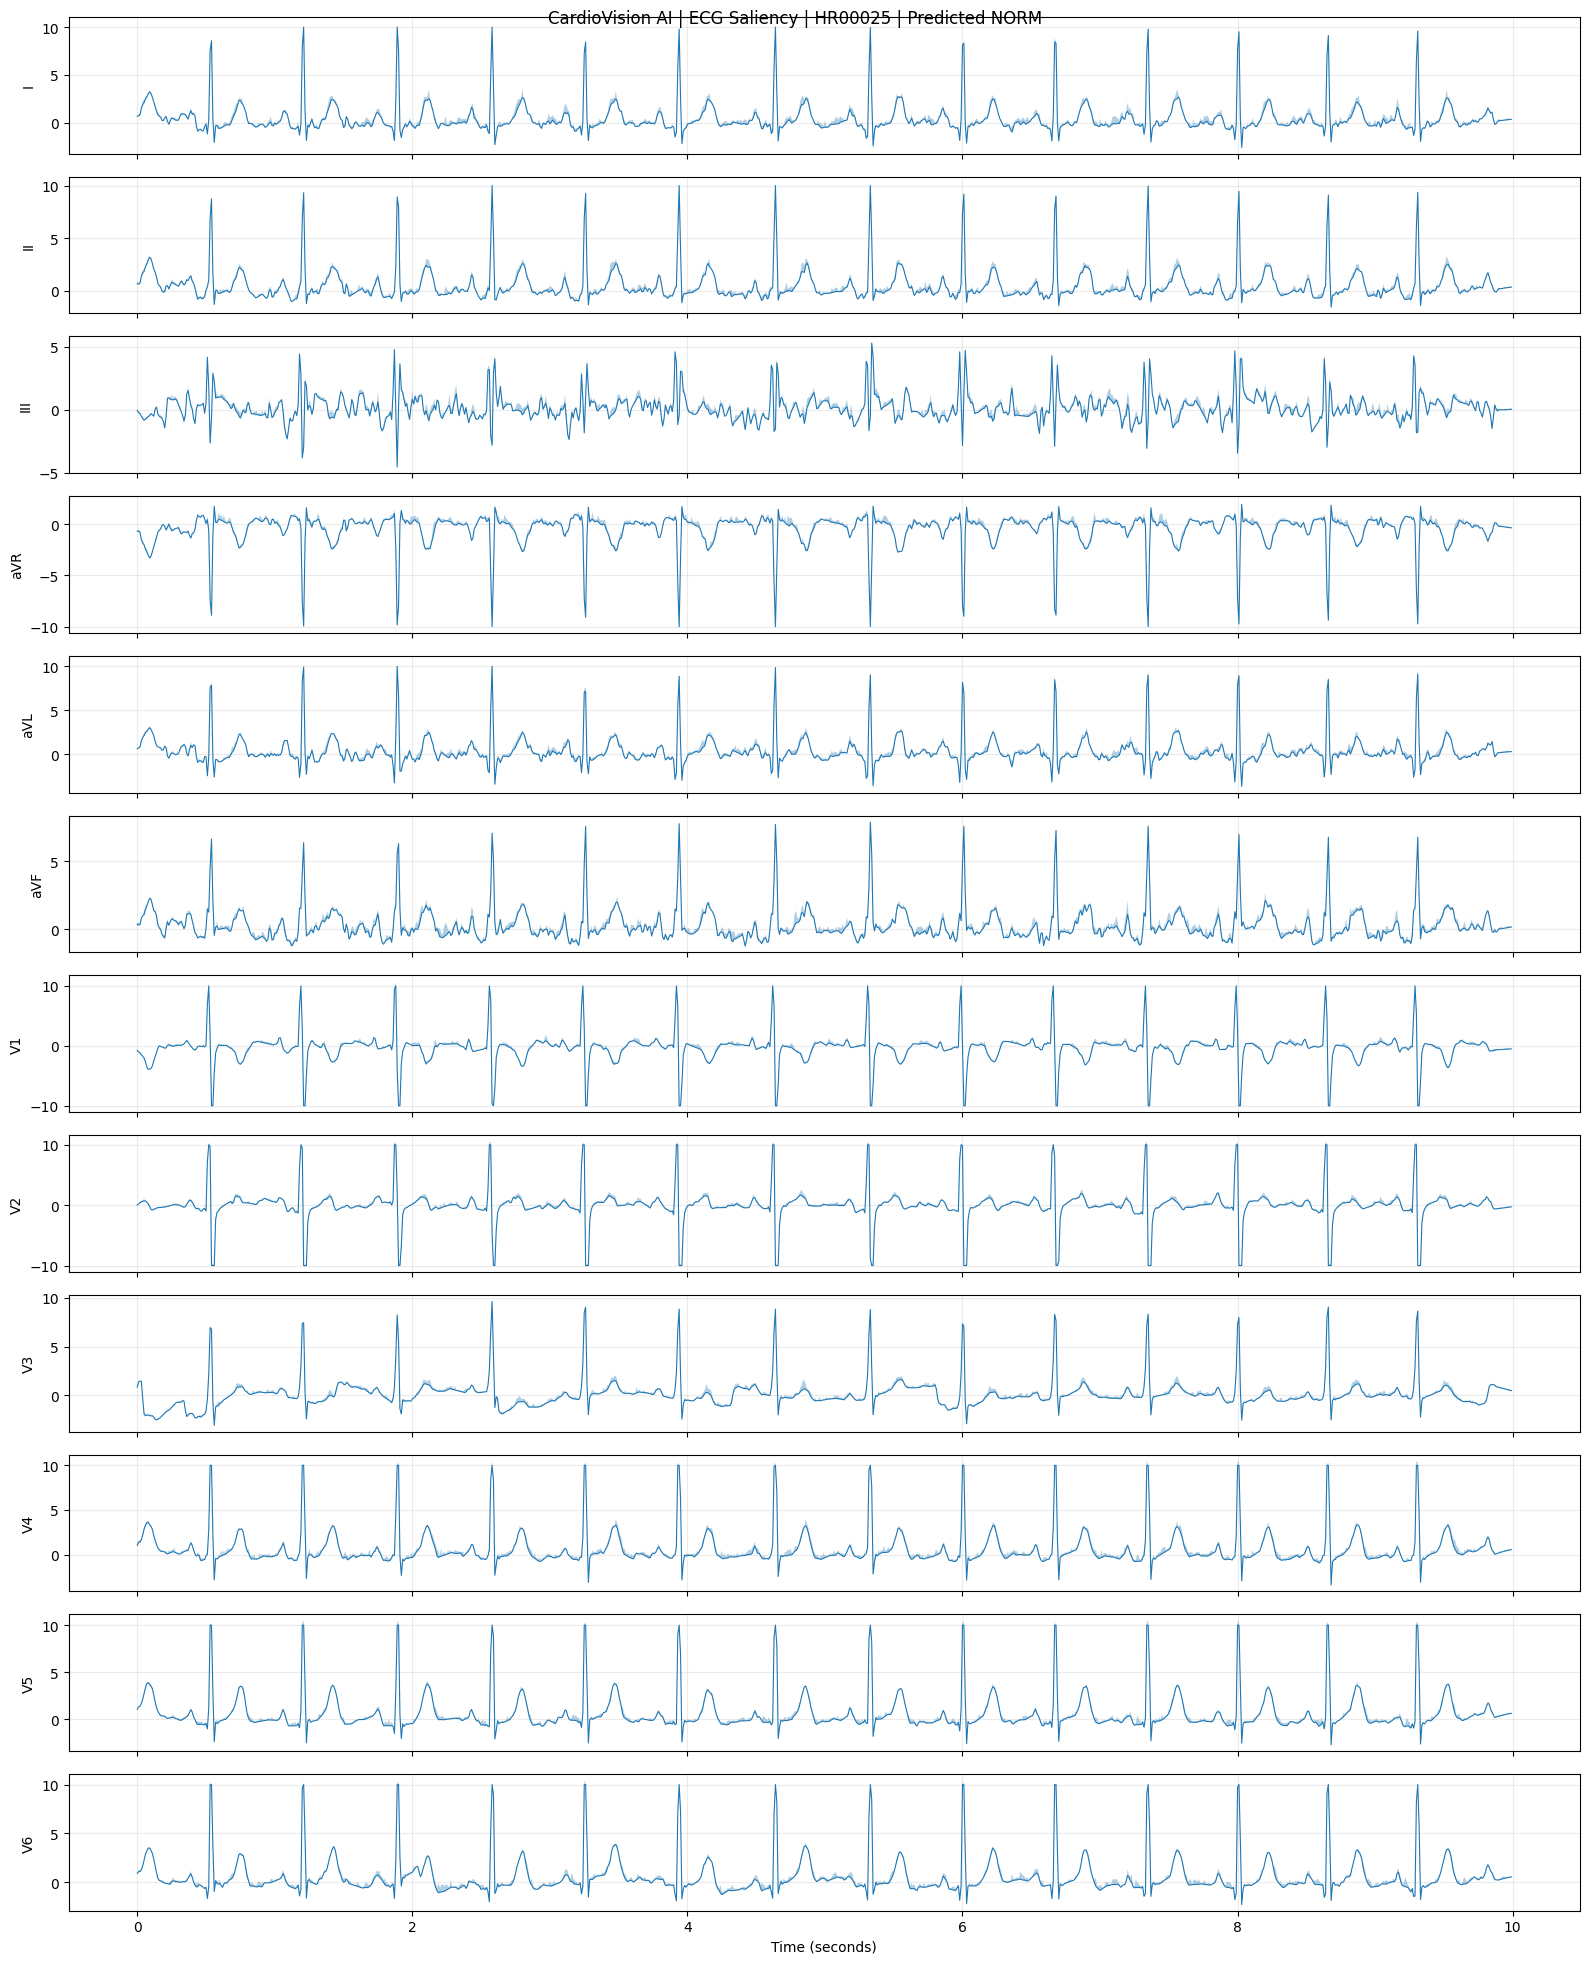


Lead importance:
   lead  mean_saliency
0     I       0.245047
9    V4       0.238707
4   aVL       0.235780
2   III       0.226594
6    V1       0.211492
11   V6       0.210837
7    V2       0.210619
1    II       0.206814
5   aVF       0.206485
3   aVR       0.205590
10   V5       0.186673
8    V3       0.161927

CARDIOVISION AI | PTB-XL PIPELINE COMPLETE

Records discovered      : 21,837
Metadata matched        : 21,799
Clinical records        : 21,388
Train records           : 14,957
Validation records      : 3,199
Test records            : 3,232

Best epoch              : 14
Best validation AUROC   : 0.9203
Test macro AUROC        : 0.9125
Test macro AP           : 0.7804
Test macro F1           : 0.7086

Patient leakage:
Train/Val : 0
Train/Test: 0
Val/Test  : 0

SAVED ARTIFACTS

Main directory:
/kaggle/working/cardioVision_PTBXL_COMPLETE

Processed ECG:
  /kaggle/working/cardioVision_PTBXL_COMPLETE/processed_data/X_train.npy
  /kaggle/working/cardioVision_PTBXL_COMPLETE/process

In [1]:
# ============================================================
# CARDIOVISION AI
# PTB-XL COMPLETE ECG PIPELINE
#
# SINGLE NOTEBOOK CELL
#
# PIPELINE
# ------------------------------------------------------------
# 1. Environment / GPU detection
# 2. WFDB file validation
# 3. Official PTB-XL metadata acquisition
# 4. Robust ECG ID matching
# 5. Clinical metadata extraction
# 6. SCP diagnostic label construction
# 7. Patient-level stratified split
# 8. ECG preprocessing
# 9. Save processed dataset for VS Code
# 10. Classical baseline models
# 11. Multilead 1D CNN
# 12. T4 mixed precision training
# 13. Class imbalance handling
# 14. Early stopping
# 15. ReduceLROnPlateau
# 16. Gradient clipping
# 17. Validation monitoring
# 18. Test evaluation
# 19. ROC / PR curves
# 20. Confusion matrices
# 21. ECG explainability / saliency
# 22. Save model checkpoints
# 23. Save preprocessing metadata
# 24. Save final results
#
# IMPORTANT
# ------------------------------------------------------------
# /kaggle/input = READ ONLY
# /kaggle/working = READ / WRITE
#
# No files are ever written to /kaggle/input.
#
# Expected local waveform structure:
#
# /kaggle/input/datasets/physionet/
#   ptbxl-electrocardiography-database/
#       WFDB/
#           HR00001.hea
#           HR00001.mat
#           ...
#
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import sys
import gc
import json
import math
import time
import random
import shutil
import warnings
import subprocess
import urllib.request
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")


# ============================================================
# 1. INSTALL / IMPORT DEPENDENCIES
# ============================================================

def ensure_package(package_name, import_name=None):

    if import_name is None:
        import_name = package_name

    try:
        __import__(import_name)

    except Exception:

        print(f"Installing {package_name}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])


ensure_package("wfdb")
ensure_package("scikit-learn", "sklearn")
ensure_package("scipy")
ensure_package("matplotlib")
ensure_package("pandas")
ensure_package("numpy")


# ============================================================
# IMPORT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb

from scipy.signal import butter, sosfiltfilt, resample_poly

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    multilabel_confusion_matrix,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
except Exception:
    pass


# ============================================================
# 3. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP_ENABLED = DEVICE.type == "cuda"

if DEVICE.type == "cuda":

    GPU_NAME = torch.cuda.get_device_name(0)

    GPU_MEMORY_GB = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

else:

    GPU_NAME = "CPU"
    GPU_MEMORY_GB = 0


print("=" * 100)
print("CARDIOVISION AI | PTB-XL COMPLETE ECG PIPELINE")
print("=" * 100)

print(f"Python          : {sys.version.split()[0]}")
print(f"PyTorch         : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"GPU             : {GPU_NAME}")
print(f"GPU Memory      : {GPU_MEMORY_GB:.2f} GB")
print(f"AMP Enabled     : {AMP_ENABLED}")


# ============================================================
# 4. CONFIGURATION
# ============================================================

ROOT = Path(
    "/kaggle/input/datasets/physionet/"
    "ptbxl-electrocardiography-database"
)

WFDB_DIR = ROOT / "WFDB"

OUTPUT_DIR = Path(
    "/kaggle/working/"
    "cardioVision_PTBXL_COMPLETE"
)

METADATA_DIR = OUTPUT_DIR / "metadata"
DATA_DIR = OUTPUT_DIR / "processed_data"
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"
PLOT_DIR = OUTPUT_DIR / "plots"
XAI_DIR = OUTPUT_DIR / "explainability"

for directory in [
    OUTPUT_DIR,
    METADATA_DIR,
    DATA_DIR,
    MODEL_DIR,
    RESULT_DIR,
    PLOT_DIR,
    XAI_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# ECG CONFIG
# ------------------------------------------------------------

ORIGINAL_FS = 500

TARGET_FS = 100

TARGET_SECONDS = 10

TARGET_LENGTH = (
    TARGET_FS *
    TARGET_SECONDS
)

N_LEADS = 12

LEAD_NAMES = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6"
]


# ------------------------------------------------------------
# SPLIT CONFIG
# ------------------------------------------------------------

TRAIN_RATIO = 0.70

VAL_RATIO = 0.15

TEST_RATIO = 0.15


# ------------------------------------------------------------
# TRAINING CONFIG
# ------------------------------------------------------------

BATCH_SIZE = 64 if GPU_MEMORY_GB >= 12 else 32

NUM_WORKERS = 2

PIN_MEMORY = DEVICE.type == "cuda"

PERSISTENT_WORKERS = NUM_WORKERS > 0

EPOCHS = 40

PATIENCE = 8

MIN_DELTA = 1e-4

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

GRADIENT_CLIP = 1.0

DROPOUT = 0.30

THRESHOLD = 0.50

MAX_TRAIN_RECORDS = None

MAX_TEST_RECORDS = None


# ============================================================
# 5. VALIDATE DATASET
# ============================================================

print("\n" + "=" * 100)
print("WFDB FILE VALIDATION")
print("=" * 100)

if not ROOT.exists():

    raise FileNotFoundError(
        f"Dataset root does not exist:\n{ROOT}"
    )

if not WFDB_DIR.exists():

    raise FileNotFoundError(
        f"WFDB directory does not exist:\n{WFDB_DIR}"
    )


hea_files = sorted(
    WFDB_DIR.glob("*.hea")
)

mat_files = sorted(
    WFDB_DIR.glob("*.mat")
)

hea_ids = {
    p.stem
    for p in hea_files
}

mat_ids = {
    p.stem
    for p in mat_files
}

matched_ids = sorted(
    hea_ids & mat_ids
)

missing_mat = sorted(
    hea_ids - mat_ids
)

missing_hea = sorted(
    mat_ids - hea_ids
)


print(
    f"Header files      : {len(hea_files):,}"
)

print(
    f"MAT files         : {len(mat_files):,}"
)

print(
    f"Matched records   : {len(matched_ids):,}"
)

print(
    f"Missing MAT       : {len(missing_mat):,}"
)

print(
    f"Missing headers   : {len(missing_hea):,}"
)


if len(matched_ids) == 0:

    raise RuntimeError(
        "No matched WFDB records were found."
    )


# ============================================================
# 6. SAFE METADATA DOWNLOAD
# ============================================================

DATABASE_URL = (
    "https://physionet.org/files/"
    "ptb-xl/1.0.3/ptbxl_database.csv"
)

SCP_URL = (
    "https://physionet.org/files/"
    "ptb-xl/1.0.3/scp_statements.csv"
)


DATABASE_INPUT = (
    ROOT /
    "ptbxl_database.csv"
)

SCP_INPUT = (
    ROOT /
    "scp_statements.csv"
)

DATABASE_WORKING = (
    METADATA_DIR /
    "ptbxl_database.csv"
)

SCP_WORKING = (
    METADATA_DIR /
    "scp_statements.csv"
)


def safe_download(
    url,
    destination
):

    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    print(
        f"\nDownloading:\n{url}"
    )

    print(
        f"To writable location:\n"
        f"{destination}"
    )

    try:

        request = urllib.request.Request(
            url,
            headers={
                "User-Agent":
                "CardioVision-AI/1.0"
            }
        )

        with urllib.request.urlopen(
            request,
            timeout=120
        ) as response:

            data = response.read()

        if len(data) == 0:

            raise RuntimeError(
                "Downloaded file is empty."
            )

        with open(
            destination,
            "wb"
        ) as f:

            f.write(data)

    except Exception as e:

        if destination.exists():

            try:
                destination.unlink()
            except Exception:
                pass

        raise RuntimeError(
            "\nCould not download official PTB-XL metadata.\n"
            f"URL: {url}\n"
            f"Destination: {destination}\n"
            f"Error: {repr(e)}\n\n"
            "The waveform dataset is present, but "
            "patient-level splitting and official "
            "clinical label construction require "
            "ptbxl_database.csv."
        )

    if not destination.exists():

        raise RuntimeError(
            "Download completed but file does not exist."
        )

    if destination.stat().st_size == 0:

        raise RuntimeError(
            "Downloaded metadata file is empty."
        )

    print(
        f"Downloaded: "
        f"{destination.stat().st_size / 1024**2:.2f} MB"
    )


# ============================================================
# 7. FIND / DOWNLOAD DATABASE METADATA
# ============================================================

print("\n" + "=" * 100)
print("OFFICIAL PTB-XL METADATA")
print("=" * 100)


if DATABASE_INPUT.exists():

    DATABASE_CSV = DATABASE_INPUT

    print(
        f"Using dataset metadata:\n"
        f"{DATABASE_CSV}"
    )

elif DATABASE_WORKING.exists():

    DATABASE_CSV = DATABASE_WORKING

    print(
        f"Using cached working metadata:\n"
        f"{DATABASE_CSV}"
    )

else:

    print(
        "Official ptbxl_database.csv not found locally."
    )

    print(
        "Downloading to /kaggle/working."
    )

    safe_download(
        DATABASE_URL,
        DATABASE_WORKING
    )

    DATABASE_CSV = DATABASE_WORKING


# ============================================================
# 8. FIND / DOWNLOAD SCP STATEMENTS
# ============================================================

if SCP_INPUT.exists():

    SCP_CSV = SCP_INPUT

    print(
        f"Using SCP metadata:\n"
        f"{SCP_CSV}"
    )

elif SCP_WORKING.exists():

    SCP_CSV = SCP_WORKING

    print(
        f"Using cached working SCP metadata:\n"
        f"{SCP_CSV}"
    )

else:

    print(
        "Official scp_statements.csv not found locally."
    )

    print(
        "Downloading to /kaggle/working."
    )

    safe_download(
        SCP_URL,
        SCP_WORKING
    )

    SCP_CSV = SCP_WORKING


# ============================================================
# 9. LOAD OFFICIAL METADATA
# ============================================================

db_df = pd.read_csv(
    DATABASE_CSV
)

scp_df = pd.read_csv(
    SCP_CSV,
    index_col=0
)


print(
    f"\nMetadata records : "
    f"{len(db_df):,}"
)

print(
    f"SCP statements   : "
    f"{len(scp_df):,}"
)


required_columns = [
    "ecg_id",
    "patient_id",
    "age",
    "sex",
    "strat_fold",
    "scp_codes"
]

missing_columns = [
    c
    for c in required_columns
    if c not in db_df.columns
]

if missing_columns:

    raise RuntimeError(
        "Missing required PTB-XL metadata columns:\n"
        + "\n".join(missing_columns)
    )


if "diagnostic_class" not in scp_df.columns:

    raise RuntimeError(
        "scp_statements.csv does not contain "
        "'diagnostic_class'."
    )


# ============================================================
# 10. ROBUST ECG ID NORMALIZATION
# ============================================================

def normalize_ecg_id(value):

    """
    Converts:
        1
        '1'
        '00001'
        'HR00001'
        'hr00001'
        'HR_00001'
    into:
        1
    """

    if pd.isna(value):

        return np.nan

    text = str(value).strip().upper()

    digits = "".join(
        c
        for c in text
        if c.isdigit()
    )

    if digits == "":

        return np.nan

    try:

        return int(digits)

    except Exception:

        return np.nan


db_df["normalized_ecg_id"] = (
    db_df["ecg_id"]
    .apply(normalize_ecg_id)
)


record_map = {}

for record_id in matched_ids:

    normalized = normalize_ecg_id(
        record_id
    )

    if not pd.isna(normalized):

        record_map[int(normalized)] = record_id


db_df["local_record_id"] = (
    db_df["normalized_ecg_id"]
    .map(record_map)
)


matched_metadata = db_df[
    db_df["local_record_id"].notna()
].copy()


print("\n" + "=" * 100)
print("ROBUST METADATA MATCHING")
print("=" * 100)

print(
    f"Official metadata records : "
    f"{len(db_df):,}"
)

print(
    f"Local WFDB records         : "
    f"{len(matched_ids):,}"
)

print(
    f"Matched metadata records   : "
    f"{len(matched_metadata):,}"
)

print(
    f"Unmatched metadata records : "
    f"{len(db_df) - len(matched_metadata):,}"
)


if len(matched_metadata) == 0:

    raise RuntimeError(
        "Zero PTB-XL records matched.\n"
        "The ECG ID normalization failed."
    )


# ============================================================
# 11. CLINICAL LABEL PARSER
# ============================================================

TARGET_CLASSES = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
]


def parse_scp_codes(value):

    if pd.isna(value):

        return {}

    text = str(value).strip()

    if text == "":
        return {}

    try:

        parsed = eval(
            text,
            {
                "__builtins__": {}
            },
            {}
        )

        if isinstance(
            parsed,
            dict
        ):

            return parsed

    except Exception:
        pass

    try:

        import ast

        parsed = ast.literal_eval(
            text
        )

        if isinstance(
            parsed,
            dict
        ):

            return parsed

    except Exception:
        pass

    return {}


# ------------------------------------------------------------
# CREATE CODE -> DIAGNOSTIC CLASS MAP
# ------------------------------------------------------------

scp_class_map = {}

for code, row in scp_df.iterrows():

    diagnostic_class = (
        row.get(
            "diagnostic_class",
            np.nan
        )
    )

    if pd.notna(
        diagnostic_class
    ):

        diagnostic_class = str(
            diagnostic_class
        ).strip()

        if diagnostic_class in TARGET_CLASSES:

            scp_class_map[
                str(code).strip()
            ] = diagnostic_class


print("\nDiagnostic SCP mappings:")

diagnostic_counter = Counter(
    scp_class_map.values()
)

print(
    diagnostic_counter
)


# ============================================================
# 12. CONSTRUCT MULTILABEL DIAGNOSTIC TARGETS
# ============================================================

def construct_labels(
    scp_codes_value
):

    codes = parse_scp_codes(
        scp_codes_value
    )

    labels = {
        cls: 0
        for cls in TARGET_CLASSES
    }

    for code in codes.keys():

        code = str(code).strip()

        diagnostic_class = (
            scp_class_map.get(
                code
            )
        )

        if diagnostic_class is not None:

            labels[
                diagnostic_class
            ] = 1

    return labels


label_rows = []

for _, row in matched_metadata.iterrows():

    labels = construct_labels(
        row["scp_codes"]
    )

    label_rows.append(
        labels
    )


label_df = pd.DataFrame(
    label_rows,
    index=matched_metadata.index
)

for cls in TARGET_CLASSES:

    matched_metadata[
        f"label_{cls}"
    ] = label_df[cls]


# ============================================================
# 13. NORM EXCLUSIVITY
# ============================================================

# PTB-XL NORM is normally used as a diagnostic category.
# If a record has NORM plus another diagnostic class,
# NORM is removed from the target because it should not
# simultaneously represent a pathological diagnostic label.

pathological_classes = [
    "MI",
    "STTC",
    "CD",
    "HYP"
]

for idx in matched_metadata.index:

    pathological = any(
        matched_metadata.loc[
            idx,
            f"label_{cls}"
        ] == 1
        for cls in pathological_classes
    )

    if pathological:

        matched_metadata.loc[
            idx,
            "label_NORM"
        ] = 0


# ============================================================
# 14. LABEL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("DIAGNOSTIC LABEL SUMMARY")
print("=" * 100)

for cls in TARGET_CLASSES:

    count = int(
        matched_metadata[
            f"label_{cls}"
        ].sum()
    )

    prevalence = (
        count /
        max(len(matched_metadata), 1)
    )

    print(
        f"{cls:5s}: "
        f"{count:6,d} "
        f"({prevalence * 100:.2f}%)"
    )


label_columns = [
    f"label_{cls}"
    for cls in TARGET_CLASSES
]


matched_metadata[
    "n_diagnostic_labels"
] = matched_metadata[
    label_columns
].sum(axis=1)


matched_metadata[
    "has_diagnostic_label"
] = (
    matched_metadata[
        "n_diagnostic_labels"
    ] > 0
)


print(
    "\nRecords before label filtering : "
    f"{len(matched_metadata):,}"
)

print(
    "Records with diagnostic labels  : "
    f"{int(matched_metadata['has_diagnostic_label'].sum()):,}"
)

print(
    "Records without target labels   : "
    f"{int((~matched_metadata['has_diagnostic_label']).sum()):,}"
)


# Keep records having at least one target diagnostic class
clinical_df = matched_metadata[
    matched_metadata[
        "has_diagnostic_label"
    ]
].copy()


if len(clinical_df) == 0:

    raise RuntimeError(
        "No records contain any target "
        "diagnostic labels."
    )


# ============================================================
# 15. BASIC CLINICAL METADATA CLEANING
# ============================================================

clinical_df["patient_id"] = pd.to_numeric(
    clinical_df["patient_id"],
    errors="coerce"
)

clinical_df["age"] = pd.to_numeric(
    clinical_df["age"],
    errors="coerce"
)

clinical_df["sex"] = pd.to_numeric(
    clinical_df["sex"],
    errors="coerce"
)

clinical_df = clinical_df[
    clinical_df["patient_id"].notna()
].copy()


clinical_df["patient_id"] = (
    clinical_df["patient_id"]
    .astype(int)
)


# ------------------------------------------------------------
# Remove impossible ages
# ------------------------------------------------------------

clinical_df.loc[
    (clinical_df["age"] < 0) |
    (clinical_df["age"] > 110),
    "age"
] = np.nan


# ------------------------------------------------------------
# Fill age using cohort median
# ------------------------------------------------------------

age_median = (
    clinical_df["age"]
    .median()
)

clinical_df["age"] = (
    clinical_df["age"]
    .fillna(age_median)
)


# ============================================================
# 16. SAVE CLINICAL METADATA
# ============================================================

clinical_metadata_path = (
    DATA_DIR /
    "ptbxl_clinical_labels.csv"
)

clinical_df.to_csv(
    clinical_metadata_path,
    index=False
)

print(
    "\nSaved clinical metadata:"
)

print(
    clinical_metadata_path
)


# ============================================================
# 17. PATIENT LEVEL SPLIT
# ============================================================

print("\n" + "=" * 100)
print("PATIENT-LEVEL SPLIT")
print("=" * 100)


# ------------------------------------------------------------
# Patient-level grouping
# ------------------------------------------------------------

patients = np.array(
    clinical_df[
        "patient_id"
    ].unique()
)

rng = np.random.default_rng(
    SEED
)

rng.shuffle(
    patients
)


# ------------------------------------------------------------
# First train/test split
# ------------------------------------------------------------

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_RATIO,
    random_state=SEED
)


indices = np.arange(
    len(clinical_df)
)

train_val_idx, test_idx = next(
    gss_test.split(
        clinical_df,
        groups=clinical_df[
            "patient_id"
        ]
    )
)


train_val_df = clinical_df.iloc[
    train_val_idx
].copy()

test_df = clinical_df.iloc[
    test_idx
].copy()


# ------------------------------------------------------------
# Validation fraction relative to train+validation
# ------------------------------------------------------------

relative_val_ratio = (
    VAL_RATIO /
    (TRAIN_RATIO + VAL_RATIO)
)


gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=relative_val_ratio,
    random_state=SEED + 1
)


train_idx, val_idx = next(
    gss_val.split(
        train_val_df,
        groups=train_val_df[
            "patient_id"
        ]
    )
)


train_df = train_val_df.iloc[
    train_idx
].copy()

val_df = train_val_df.iloc[
    val_idx
].copy()


# ------------------------------------------------------------
# Verify no patient leakage
# ------------------------------------------------------------

train_patients = set(
    train_df["patient_id"]
)

val_patients = set(
    val_df["patient_id"]
)

test_patients = set(
    test_df["patient_id"]
)


train_val_overlap = (
    train_patients &
    val_patients
)

train_test_overlap = (
    train_patients &
    test_patients
)

val_test_overlap = (
    val_patients &
    test_patients
)


print(
    f"Train records      : "
    f"{len(train_df):,}"
)

print(
    f"Validation records : "
    f"{len(val_df):,}"
)

print(
    f"Test records       : "
    f"{len(test_df):,}"
)

print(
    f"Train patients     : "
    f"{len(train_patients):,}"
)

print(
    f"Validation patients: "
    f"{len(val_patients):,}"
)

print(
    f"Test patients      : "
    f"{len(test_patients):,}"
)

print(
    f"\nTrain/Val overlap  : "
    f"{len(train_val_overlap)}"
)

print(
    f"Train/Test overlap : "
    f"{len(train_test_overlap)}"
)

print(
    f"Val/Test overlap   : "
    f"{len(val_test_overlap)}"
)


if (
    train_val_overlap or
    train_test_overlap or
    val_test_overlap
):

    raise RuntimeError(
        "PATIENT LEAKAGE DETECTED."
    )


# ------------------------------------------------------------
# Save split metadata
# ------------------------------------------------------------

train_df[
    "split"
] = "train"

val_df[
    "split"
] = "validation"

test_df[
    "split"
] = "test"


split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    axis=0
)


split_path = (
    DATA_DIR /
    "ptbxl_patient_level_splits.csv"
)

split_df.to_csv(
    split_path,
    index=False
)


# ============================================================
# 18. OPTIONAL RECORD LIMIT
# ============================================================

if MAX_TRAIN_RECORDS is not None:

    train_df = train_df.head(
        MAX_TRAIN_RECORDS
    ).copy()


if MAX_TEST_RECORDS is not None:

    test_df = test_df.head(
        MAX_TEST_RECORDS
    ).copy()


print(
    "\nFinal records used:"
)

print(
    f"Train      : {len(train_df):,}"
)

print(
    f"Validation : {len(val_df):,}"
)

print(
    f"Test       : {len(test_df):,}"
)


if len(train_df) == 0:

    raise RuntimeError(
        "Training set is empty."
    )

if len(val_df) == 0:

    raise RuntimeError(
        "Validation set is empty."
    )

if len(test_df) == 0:

    raise RuntimeError(
        "Test set is empty."
    )


# ============================================================
# 19. ECG PREPROCESSING FUNCTIONS
# ============================================================

print("\n" + "=" * 100)
print("ECG PREPROCESSING")
print("=" * 100)


# ------------------------------------------------------------
# Bandpass filter
# ------------------------------------------------------------

def bandpass_filter(
    signal,
    fs,
    lowcut=0.5,
    highcut=40.0,
    order=4
):

    try:

        sos = butter(
            order,
            [
                lowcut,
                highcut
            ],
            btype="bandpass",
            fs=fs,
            output="sos"
        )

        filtered = sosfiltfilt(
            sos,
            signal,
            axis=0
        )

        return filtered.astype(
            np.float32
        )

    except Exception:

        return signal.astype(
            np.float32
        )


# ------------------------------------------------------------
# Robust per-lead normalization
# ------------------------------------------------------------

def robust_normalize(
    signal
):

    signal = np.asarray(
        signal,
        dtype=np.float32
    )

    median = np.median(
        signal,
        axis=0,
        keepdims=True
    )

    q25 = np.percentile(
        signal,
        25,
        axis=0,
        keepdims=True
    )

    q75 = np.percentile(
        signal,
        75,
        axis=0,
        keepdims=True
    )

    scale = (
        q75 -
        q25
    )

    scale[
        scale < 1e-6
    ] = 1.0

    signal = (
        signal -
        median
    ) / scale

    signal = np.clip(
        signal,
        -10.0,
        10.0
    )

    return signal.astype(
        np.float32
    )


# ------------------------------------------------------------
# Resample
# ------------------------------------------------------------

def resample_ecg(
    signal,
    original_fs,
    target_fs
):

    if original_fs == target_fs:

        return signal

    gcd = math.gcd(
        int(original_fs),
        int(target_fs)
    )

    up = (
        int(target_fs) //
        gcd
    )

    down = (
        int(original_fs) //
        gcd
    )

    resampled = resample_poly(
        signal,
        up,
        down,
        axis=0
    )

    return resampled.astype(
        np.float32
    )


# ------------------------------------------------------------
# Fixed length
# ------------------------------------------------------------

def fix_length(
    signal,
    target_length
):

    n_samples = signal.shape[0]

    if n_samples == target_length:

        return signal

    if n_samples > target_length:

        return signal[
            :target_length
        ]

    pad_length = (
        target_length -
        n_samples
    )

    return np.pad(
        signal,
        (
            (0, pad_length),
            (0, 0)
        ),
        mode="constant"
    ).astype(
        np.float32
    )


# ------------------------------------------------------------
# Complete ECG preprocessing
# ------------------------------------------------------------

def preprocess_ecg(
    signal,
    fs
):

    signal = np.asarray(
        signal,
        dtype=np.float32
    )

    if signal.ndim != 2:

        raise ValueError(
            f"Expected 2D ECG, "
            f"got {signal.shape}"
        )

    if signal.shape[1] != N_LEADS:

        raise ValueError(
            f"Expected {N_LEADS} leads, "
            f"got {signal.shape[1]}"
        )

    if not np.isfinite(
        signal
    ).all():

        raise ValueError(
            "ECG contains non-finite values."
        )

    signal = bandpass_filter(
        signal,
        fs
    )

    signal = resample_ecg(
        signal,
        int(fs),
        TARGET_FS
    )

    signal = fix_length(
        signal,
        TARGET_LENGTH
    )

    signal = robust_normalize(
        signal
    )

    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return signal.astype(
        np.float32
    )


# ============================================================
# 20. PROCESS ALL ECG RECORDS
# ============================================================

def process_dataframe(
    dataframe,
    split_name
):

    processed = []

    failures = []

    total = len(dataframe)

    for counter, (_, row) in enumerate(
        dataframe.iterrows(),
        start=1
    ):

        record_id = str(
            row["local_record_id"]
        )

        try:

            record_path = (
                WFDB_DIR /
                record_id
            )

            signal, fields = wfdb.rdsamp(
                str(record_path)
            )

            fs = float(
                fields["fs"]
            )

            processed_signal = (
                preprocess_ecg(
                    signal,
                    fs
                )
            )

            processed.append(
                processed_signal
            )

        except Exception as e:

            failures.append(
                {
                    "record_id": record_id,
                    "error": repr(e)
                }
            )

        if counter % 500 == 0:

            print(
                f"{split_name}: "
                f"{counter:,}/{total:,}"
            )

    if len(processed) == 0:

        raise RuntimeError(
            f"No ECG records could be "
            f"processed for {split_name}."
        )

    array = np.stack(
        processed,
        axis=0
    ).astype(
        np.float32
    )

    return (
        array,
        failures
    )


X_train, train_failures = process_dataframe(
    train_df,
    "TRAIN"
)

X_val, val_failures = process_dataframe(
    val_df,
    "VALIDATION"
)

X_test, test_failures = process_dataframe(
    test_df,
    "TEST"
)


# ============================================================
# 21. ALIGN METADATA AFTER PROCESSING
# ============================================================

# If any records failed preprocessing, retain only
# successfully processed records.

def get_successful_ids(
    dataframe,
    failures
):

    failed_ids = {
        x["record_id"]
        for x in failures
    }

    mask = ~dataframe[
        "local_record_id"
    ].astype(str).isin(
        failed_ids
    )

    return dataframe[
        mask
    ].copy()


train_df_clean = get_successful_ids(
    train_df,
    train_failures
)

val_df_clean = get_successful_ids(
    val_df,
    val_failures
)

test_df_clean = get_successful_ids(
    test_df,
    test_failures
)


# ============================================================
# 22. SAVE PREPROCESSING FAILURES
# ============================================================

all_failures = (
    [
        {
            **x,
            "split": "train"
        }
        for x in train_failures
    ]
    +
    [
        {
            **x,
            "split": "validation"
        }
        for x in val_failures
    ]
    +
    [
        {
            **x,
            "split": "test"
        }
        for x in test_failures
    ]
)


failures_path = (
    RESULT_DIR /
    "preprocessing_failures.csv"
)

pd.DataFrame(
    all_failures
).to_csv(
    failures_path,
    index=False
)


# ============================================================
# 23. SAVE PROCESSED ECG DATA
# ============================================================

print("\nSaving processed ECG arrays...")


train_array_path = (
    DATA_DIR /
    "X_train.npy"
)

val_array_path = (
    DATA_DIR /
    "X_validation.npy"
)

test_array_path = (
    DATA_DIR /
    "X_test.npy"
)


np.save(
    train_array_path,
    X_train
)

np.save(
    val_array_path,
    X_val
)

np.save(
    test_array_path,
    X_test
)


# ------------------------------------------------------------
# Save labels
# ------------------------------------------------------------

Y_train = (
    train_df_clean[
        label_columns
    ]
    .values
    .astype(np.float32)
)

Y_val = (
    val_df_clean[
        label_columns
    ]
    .values
    .astype(np.float32)
)

Y_test = (
    test_df_clean[
        label_columns
    ]
    .values
    .astype(np.float32)
)


np.save(
    DATA_DIR /
    "Y_train.npy",
    Y_train
)

np.save(
    DATA_DIR /
    "Y_validation.npy",
    Y_val
)

np.save(
    DATA_DIR /
    "Y_test.npy",
    Y_test
)


# ------------------------------------------------------------
# Save clean metadata
# ------------------------------------------------------------

train_df_clean.to_csv(
    DATA_DIR /
    "train_metadata.csv",
    index=False
)

val_df_clean.to_csv(
    DATA_DIR /
    "validation_metadata.csv",
    index=False
)

test_df_clean.to_csv(
    DATA_DIR /
    "test_metadata.csv",
    index=False
)


# ============================================================
# 24. SAVE PREPROCESSING CONFIG
# ============================================================

preprocessing_config = {

    "original_sampling_frequency":
        ORIGINAL_FS,

    "target_sampling_frequency":
        TARGET_FS,

    "duration_seconds":
        TARGET_SECONDS,

    "target_length":
        TARGET_LENGTH,

    "n_leads":
        N_LEADS,

    "lead_names":
        LEAD_NAMES,

    "bandpass_low_hz":
        0.5,

    "bandpass_high_hz":
        40.0,

    "normalization":
        "per-lead robust median/IQR",

    "clip_range":
        [-10.0, 10.0],

    "seed":
        SEED
}


with open(
    DATA_DIR /
    "preprocessing_config.json",
    "w"
) as f:

    json.dump(
        preprocessing_config,
        f,
        indent=4
    )


# ============================================================
# 25. PREPROCESSING SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("PREPROCESSING SUMMARY")
print("=" * 100)

print(
    f"Train shape      : {X_train.shape}"
)

print(
    f"Validation shape : {X_val.shape}"
)

print(
    f"Test shape       : {X_test.shape}"
)

print(
    f"Dtype            : {X_train.dtype}"
)

print(
    f"Train finite     : "
    f"{np.isfinite(X_train).mean():.6f}"
)

print(
    f"Train mean       : "
    f"{X_train.mean():.6f}"
)

print(
    f"Train std        : "
    f"{X_train.std():.6f}"
)

print(
    f"Train failures   : "
    f"{len(train_failures):,}"
)

print(
    f"Validation fail. : "
    f"{len(val_failures):,}"
)

print(
    f"Test failures    : "
    f"{len(test_failures):,}"
)


# ============================================================
# 26. SAFETY CHECKS BEFORE TRAINING
# ============================================================

if len(X_train) == 0:

    raise RuntimeError(
        "X_train is empty."
    )

if len(X_val) == 0:

    raise RuntimeError(
        "X_validation is empty."
    )

if len(X_test) == 0:

    raise RuntimeError(
        "X_test is empty."
    )

if len(Y_train) == 0:

    raise RuntimeError(
        "Y_train is empty."
    )

if len(Y_train) != len(X_train):

    raise RuntimeError(
        "X_train and Y_train lengths differ."
    )

if len(Y_val) != len(X_val):

    raise RuntimeError(
        "X_validation and Y_validation lengths differ."
    )

if len(Y_test) != len(X_test):

    raise RuntimeError(
        "X_test and Y_test lengths differ."
    )


# ============================================================
# 27. DATASET
# ============================================================

class PTBXLDataset(
    Dataset
):

    def __init__(
        self,
        X,
        Y,
        train=False
    ):

        self.X = X

        self.Y = Y

        self.train = train


    def __len__(
        self
    ):

        return len(
            self.X
        )


    def __getitem__(
        self,
        index
    ):

        x = self.X[index]

        y = self.Y[index]

        # ----------------------------------------------------
        # Lightweight augmentation
        # Applied only during training
        # ----------------------------------------------------

        if self.train:

            x = x.copy()

            # Gaussian noise
            if random.random() < 0.30:

                noise = np.random.normal(
                    0,
                    0.01,
                    size=x.shape
                ).astype(
                    np.float32
                )

                x += noise

            # Amplitude scaling
            if random.random() < 0.20:

                scale = np.random.uniform(
                    0.90,
                    1.10
                )

                x *= scale

            # Small temporal shift
            if random.random() < 0.15:

                shift = np.random.randint(
                    -10,
                    11
                )

                x = np.roll(
                    x,
                    shift,
                    axis=1
                )

        x = torch.from_numpy(
            x.T.copy()
        ).float()

        y = torch.from_numpy(
            y.copy()
        ).float()

        return x, y


train_dataset = PTBXLDataset(
    X_train,
    Y_train,
    train=True
)

val_dataset = PTBXLDataset(
    X_val,
    Y_val,
    train=False
)

test_dataset = PTBXLDataset(
    X_test,
    Y_test,
    train=False
)


# ============================================================
# 28. CLASS IMBALANCE
# ============================================================

positive_counts = (
    Y_train.sum(axis=0)
)

negative_counts = (
    len(Y_train) -
    positive_counts
)


pos_weight = (
    negative_counts /
    np.maximum(
        positive_counts,
        1
    )
)


# Avoid extreme gradients from extremely rare classes

pos_weight = np.clip(
    pos_weight,
    1.0,
    20.0
)


print("\n" + "=" * 100)
print("CLASS BALANCING")
print("=" * 100)

for i, cls in enumerate(
    TARGET_CLASSES
):

    print(
        f"{cls:5s} | "
        f"Positive: "
        f"{int(positive_counts[i]):6,d} | "
        f"Negative: "
        f"{int(negative_counts[i]):6,d} | "
        f"pos_weight: "
        f"{pos_weight[i]:.3f}"
    )


# ============================================================
# 29. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    drop_last=False
)


# ============================================================
# 30. MODEL
# ============================================================

class ConvBlock(
    nn.Module
):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=7,
        stride=1,
        dropout=0.0
    ):

        super().__init__()

        padding = (
            kernel_size // 2
        )

        self.block = nn.Sequential(

            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size,
                stride=stride,
                padding=padding,
                bias=False
            ),

            nn.BatchNorm1d(
                out_channels
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            )

        )


    def forward(
        self,
        x
    ):

        return self.block(x)


class ECGResNet1D(
    nn.Module
):

    def __init__(
        self,
        n_classes=5,
        dropout=0.30
    ):

        super().__init__()

        self.stem = nn.Sequential(

            nn.Conv1d(
                12,
                64,
                kernel_size=15,
                stride=2,
                padding=7,
                bias=False
            ),

            nn.BatchNorm1d(
                64
            ),

            nn.GELU(),

            nn.MaxPool1d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )


        self.block1 = nn.Sequential(

            ConvBlock(
                64,
                64,
                kernel_size=7,
                dropout=dropout
            ),

            ConvBlock(
                64,
                64,
                kernel_size=7,
                dropout=dropout
            )
        )


        self.down1 = nn.Conv1d(
            64,
            128,
            kernel_size=1,
            stride=2,
            bias=False
        )

        self.block2 = nn.Sequential(

            ConvBlock(
                128,
                128,
                kernel_size=7,
                dropout=dropout
            ),

            ConvBlock(
                128,
                128,
                kernel_size=7,
                dropout=dropout
            )
        )


        self.down2 = nn.Conv1d(
            128,
            256,
            kernel_size=1,
            stride=2,
            bias=False
        )

        self.block3 = nn.Sequential(

            ConvBlock(
                256,
                256,
                kernel_size=5,
                dropout=dropout
            ),

            ConvBlock(
                256,
                256,
                kernel_size=5,
                dropout=dropout
            )
        )


        self.down3 = nn.Conv1d(
            256,
            512,
            kernel_size=1,
            stride=2,
            bias=False
        )

        self.block4 = nn.Sequential(

            ConvBlock(
                512,
                512,
                kernel_size=5,
                dropout=dropout
            ),

            ConvBlock(
                512,
                512,
                kernel_size=5,
                dropout=dropout
            )
        )


        self.pool = nn.AdaptiveAvgPool1d(
            1
        )


        self.classifier = nn.Sequential(

            nn.Linear(
                512,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.GELU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                256,
                n_classes
            )
        )


    def forward(
        self,
        x
    ):

        x = self.stem(x)

        residual = x

        x = self.block1(x)

        x = x + residual

        residual = self.down1(x)

        x = self.block2(
            residual
        )

        x = x + residual

        residual = self.down2(x)

        x = self.block3(
            residual
        )

        x = x + residual

        residual = self.down3(x)

        x = self.block4(
            residual
        )

        x = x + residual

        x = self.pool(
            x
        )

        x = torch.flatten(
            x,
            1
        )

        return self.classifier(
            x
        )


model = ECGResNet1D(
    n_classes=len(
        TARGET_CLASSES
    ),
    dropout=DROPOUT
).to(
    DEVICE
)


print("\n" + "=" * 100)
print("MODEL")
print("=" * 100)

print(
    model
)


parameter_count = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\nTotal parameters     : "
    f"{parameter_count:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameter_count:,}"
)


# ============================================================
# 31. LOSS / OPTIMIZER
# ============================================================

pos_weight_tensor = torch.tensor(
    pos_weight,
    dtype=torch.float32,
    device=DEVICE
)


criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# PyTorch 2.10 compatible AMP

if AMP_ENABLED:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


# ============================================================
# 32. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_prob,
    threshold=0.5
):

    y_true = np.asarray(
        y_true
    )

    y_prob = np.asarray(
        y_prob
    )

    y_pred = (
        y_prob >= threshold
    ).astype(
        np.int32
    )

    metrics = {}

    auc_values = []

    ap_values = []

    f1_values = []

    precision_values = []

    recall_values = []

    for i, cls in enumerate(
        TARGET_CLASSES
    ):

        true = y_true[:, i]

        prob = y_prob[:, i]

        pred = y_pred[:, i]

        if len(
            np.unique(true)
        ) >= 2:

            try:

                auc = roc_auc_score(
                    true,
                    prob
                )

            except Exception:

                auc = np.nan

            try:

                ap = average_precision_score(
                    true,
                    prob
                )

            except Exception:

                ap = np.nan

        else:

            auc = np.nan
            ap = np.nan


        f1 = f1_score(
            true,
            pred,
            zero_division=0
        )

        precision = precision_score(
            true,
            pred,
            zero_division=0
        )

        recall = recall_score(
            true,
            pred,
            zero_division=0
        )


        metrics[
            f"{cls}_AUROC"
        ] = auc

        metrics[
            f"{cls}_AP"
        ] = ap

        metrics[
            f"{cls}_F1"
        ] = f1

        metrics[
            f"{cls}_Precision"
        ] = precision

        metrics[
            f"{cls}_Recall"
        ] = recall


        if not np.isnan(auc):
            auc_values.append(auc)

        if not np.isnan(ap):
            ap_values.append(ap)

        f1_values.append(f1)

        precision_values.append(
            precision
        )

        recall_values.append(
            recall
        )


    metrics[
        "macro_AUROC"
    ] = (
        np.mean(auc_values)
        if auc_values
        else np.nan
    )

    metrics[
        "macro_AP"
    ] = (
        np.mean(ap_values)
        if ap_values
        else np.nan
    )

    metrics[
        "macro_F1"
    ] = np.mean(
        f1_values
    )

    metrics[
        "macro_Precision"
    ] = np.mean(
        precision_values
    )

    metrics[
        "macro_Recall"
    ] = np.mean(
        recall_values
    )


    return metrics


# ============================================================
# 33. TRAIN / VALIDATION FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler
):

    model.train()

    running_loss = 0.0

    total = 0

    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        if AMP_ENABLED:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                logits = model(x)

                loss = criterion(
                    logits,
                    y
                )

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRADIENT_CLIP
            )

            optimizer.step()


        batch_size = x.size(0)

        running_loss += (
            loss.item() *
            batch_size
        )

        total += batch_size


    return (
        running_loss /
        max(total, 1)
    )


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    total = 0

    all_targets = []

    all_probs = []


    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        if AMP_ENABLED:

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                logits = model(x)

                loss = criterion(
                    logits,
                    y
                )

        else:

            logits = model(x)

            loss = criterion(
                logits,
                y
            )


        probs = torch.sigmoid(
            logits
        )


        batch_size = x.size(0)

        running_loss += (
            loss.item() *
            batch_size
        )

        total += batch_size

        all_targets.append(
            y.detach()
            .cpu()
            .numpy()
        )

        all_probs.append(
            probs.detach()
            .cpu()
            .numpy()
        )


    y_true = np.concatenate(
        all_targets,
        axis=0
    )

    y_prob = np.concatenate(
        all_probs,
        axis=0
    )

    avg_loss = (
        running_loss /
        max(total, 1)
    )

    metrics = calculate_metrics(
        y_true,
        y_prob,
        THRESHOLD
    )

    return (
        avg_loss,
        metrics,
        y_true,
        y_prob
    )


# ============================================================
# 34. TRAINING LOOP
# ============================================================

print("\n" + "=" * 100)
print("MODEL TRAINING")
print("=" * 100)

best_score = -np.inf

best_epoch = 0

epochs_without_improvement = 0

history = []


best_model_path = (
    MODEL_DIR /
    "best_ecg_resnet1d.pt"
)


for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()


    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scaler
    )


    val_loss, val_metrics, _, _ = (
        evaluate_model(
            model,
            val_loader,
            criterion
        )
    )


    val_auc = (
        val_metrics[
            "macro_AUROC"
        ]
    )


    if np.isnan(val_auc):

        val_auc = (
            -np.inf
        )


    scheduler.step(
        val_auc
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    epoch_time = (
        time.time() -
        epoch_start
    )


    row = {

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "val_macro_AUROC":
            val_metrics[
                "macro_AUROC"
            ],

        "val_macro_AP":
            val_metrics[
                "macro_AP"
            ],

        "val_macro_F1":
            val_metrics[
                "macro_F1"
            ],

        "learning_rate":
            current_lr,

        "epoch_seconds":
            epoch_time
    }


    history.append(
        row
    )


    print(
        f"Epoch "
        f"{epoch:02d}/{EPOCHS} | "
        f"Train Loss "
        f"{train_loss:.4f} | "
        f"Val Loss "
        f"{val_loss:.4f} | "
        f"Val AUROC "
        f"{val_metrics['macro_AUROC']:.4f} | "
        f"Val AP "
        f"{val_metrics['macro_AP']:.4f} | "
        f"Val F1 "
        f"{val_metrics['macro_F1']:.4f} | "
        f"LR "
        f"{current_lr:.2e} | "
        f"{epoch_time:.1f}s"
    )


    # --------------------------------------------------------
    # Save best model only
    # --------------------------------------------------------

    if (
        val_auc >
        best_score + MIN_DELTA
    ):

        best_score = val_auc

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_macro_AUROC":
                    float(best_score),

                "target_classes":
                    TARGET_CLASSES,

                "lead_names":
                    LEAD_NAMES,

                "target_fs":
                    TARGET_FS,

                "target_length":
                    TARGET_LENGTH
            },
            best_model_path
        )


        print(
            "  -> BEST MODEL SAVED"
        )

    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            f"\nEarly stopping at "
            f"epoch {epoch}."
        )

        print(
            f"Best epoch: "
            f"{best_epoch}"
        )

        print(
            f"Best validation AUROC: "
            f"{best_score:.4f}"
        )

        break


# ============================================================
# 35. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)

history_path = (
    RESULT_DIR /
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# 36. LOAD BEST MODEL
# ============================================================

if not best_model_path.exists():

    raise RuntimeError(
        "Best model checkpoint was not created."
    )


checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
    weights_only=False
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


print("\n" + "=" * 100)
print("BEST MODEL RESTORED")
print("=" * 100)

print(
    f"Best epoch : "
    f"{checkpoint['epoch']}"
)

print(
    f"Best Val AUROC : "
    f"{checkpoint['best_val_macro_AUROC']:.4f}"
)


# ============================================================
# 37. FINAL TEST EVALUATION
# ============================================================

print("\n" + "=" * 100)
print("FINAL TEST EVALUATION")
print("=" * 100)


test_loss, test_metrics, y_test_true, y_test_prob = (
    evaluate_model(
        model,
        test_loader,
        criterion
    )
)


for key, value in test_metrics.items():

    print(
        f"{key:25s}: "
        f"{value:.4f}"
    )


print(
    f"\nTest loss: "
    f"{test_loss:.4f}"
)


# ============================================================
# 38. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = pd.DataFrame()

prediction_df[
    "record_id"
] = test_df_clean[
    "local_record_id"
].astype(str).values

prediction_df[
    "patient_id"
] = test_df_clean[
    "patient_id"
].values


for i, cls in enumerate(
    TARGET_CLASSES
):

    prediction_df[
        f"true_{cls}"
    ] = y_test_true[:, i]

    prediction_df[
        f"prob_{cls}"
    ] = y_test_prob[:, i]

    prediction_df[
        f"pred_{cls}"
    ] = (
        y_test_prob[:, i]
        >= THRESHOLD
    ).astype(int)


predictions_path = (
    RESULT_DIR /
    "test_predictions.csv"
)

prediction_df.to_csv(
    predictions_path,
    index=False
)


# ============================================================
# 39. SAVE FINAL METRICS
# ============================================================

metrics_path = (
    RESULT_DIR /
    "test_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        {
            k: (
                None
                if pd.isna(v)
                else float(v)
            )
            for k, v
            in test_metrics.items()
        },
        f,
        indent=4
    )


# ============================================================
# 40. ROC CURVES
# ============================================================

plt.figure(
    figsize=(10, 8)
)

for i, cls in enumerate(
    TARGET_CLASSES
):

    true = y_test_true[:, i]

    prob = y_test_prob[:, i]

    if len(
        np.unique(true)
    ) < 2:

        continue

    fpr, tpr, _ = roc_curve(
        true,
        prob
    )

    auc = roc_auc_score(
        true,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} AUROC={auc:.3f}"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "PTB-XL Test ROC Curves"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

roc_path = (
    PLOT_DIR /
    "test_roc_curves.png"
)

plt.savefig(
    roc_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 41. PRECISION RECALL CURVES
# ============================================================

plt.figure(
    figsize=(10, 8)
)

for i, cls in enumerate(
    TARGET_CLASSES
):

    true = y_test_true[:, i]

    prob = y_test_prob[:, i]

    if len(
        np.unique(true)
    ) < 2:

        continue

    precision, recall, _ = (
        precision_recall_curve(
            true,
            prob
        )
    )

    ap = average_precision_score(
        true,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{cls} AP={ap:.3f}"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "PTB-XL Test Precision-Recall Curves"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

pr_path = (
    PLOT_DIR /
    "test_precision_recall_curves.png"
)

plt.savefig(
    pr_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 42. MULTILABEL CONFUSION MATRICES
# ============================================================

cms = multilabel_confusion_matrix(
    y_test_true,
    (
        y_test_prob >= THRESHOLD
    ).astype(int)
)


for i, cls in enumerate(
    TARGET_CLASSES
):

    cm = cms[i]

    plt.figure(
        figsize=(5, 4)
    )

    plt.imshow(
        cm
    )

    plt.title(
        f"{cls} Confusion Matrix"
    )

    plt.xticks(
        [0, 1],
        ["Pred 0", "Pred 1"]
    )

    plt.yticks(
        [0, 1],
        ["True 0", "True 1"]
    )

    for r in range(2):

        for c in range(2):

            plt.text(
                c,
                r,
                str(cm[r, c]),
                ha="center",
                va="center"
            )

    plt.xlabel(
        "Prediction"
    )

    plt.ylabel(
        "Ground Truth"
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        f"confusion_matrix_{cls}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# 43. TRAINING CURVES
# ============================================================

if len(history_df) > 0:

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.title(
        "Training / Validation Loss"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        "training_validation_loss.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_macro_AUROC"],
        marker="o"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Validation Macro AUROC"
    )

    plt.title(
        "Validation AUROC"
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR /
        "validation_auroc.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()


# ============================================================
# 44. EXPLAINABILITY
# ============================================================

print("\n" + "=" * 100)
print("ECG EXPLAINABILITY")
print("=" * 100)


class ECGSaliency:

    def __init__(
        self,
        model
    ):

        self.model = model


    def generate(
        self,
        x,
        target_class
    ):

        self.model.eval()

        x = x.clone().detach()

        x.requires_grad_()

        self.model.zero_grad(
            set_to_none=True
        )

        logits = self.model(
            x
        )

        target = logits[
            0,
            target_class
        ]

        target.backward()

        saliency = (
            x.grad
            .detach()
            .abs()
            .cpu()
            .numpy()
        )

        saliency = (
            saliency[0]
        )

        # Normalize per lead
        denominator = (
            saliency.max(
                axis=1,
                keepdims=True
            ) + 1e-8
        )

        saliency = (
            saliency /
            denominator
        )

        return saliency


# ------------------------------------------------------------
# Select representative test record
# ------------------------------------------------------------

sample_index = 0

sample_x = (
    torch.from_numpy(
        X_test[
            sample_index
        ].T
    )
    .float()
    .unsqueeze(0)
    .to(DEVICE)
)


with torch.no_grad():

    sample_logits = model(
        sample_x
    )

    sample_probs = torch.sigmoid(
        sample_logits
    )[0].cpu().numpy()


predicted_class = int(
    np.argmax(
        sample_probs
    )
)


saliency_engine = ECGSaliency(
    model
)


saliency = saliency_engine.generate(
    sample_x,
    predicted_class
)


# ============================================================
# 45. SALIENCY PLOT
# ============================================================

record_id = str(
    test_df_clean.iloc[
        sample_index
    ]["local_record_id"]
)

time_axis = (
    np.arange(
        TARGET_LENGTH
    ) /
    TARGET_FS
)


fig, axes = plt.subplots(
    N_LEADS,
    1,
    figsize=(16, 20),
    sharex=True
)


for lead_index in range(
    N_LEADS
):

    signal = X_test[
        sample_index,
        :,
        lead_index
    ]

    importance = saliency[
        lead_index
    ]

    axes[
        lead_index
    ].plot(
        time_axis,
        signal,
        linewidth=0.8
    )

    axes[
        lead_index
    ].fill_between(
        time_axis,
        signal,
        signal +
        importance,
        alpha=0.35
    )

    axes[
        lead_index
    ].set_ylabel(
        LEAD_NAMES[
            lead_index
        ]
    )

    axes[
        lead_index
    ].grid(
        alpha=0.25
    )


axes[
    -1
].set_xlabel(
    "Time (seconds)"
)


fig.suptitle(
    "CardioVision AI | ECG Saliency | "
    f"{record_id} | "
    f"Predicted {TARGET_CLASSES[predicted_class]}"
)


plt.tight_layout()

xai_plot_path = (
    XAI_DIR /
    f"{record_id}_saliency.png"
)

plt.savefig(
    xai_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 46. SAVE SALIENCY NUMERIC DATA
# ============================================================

saliency_df = pd.DataFrame(
    saliency.T,
    columns=LEAD_NAMES
)

saliency_df[
    "time_seconds"
] = time_axis


saliency_csv_path = (
    XAI_DIR /
    f"{record_id}_saliency.csv"
)

saliency_df.to_csv(
    saliency_csv_path,
    index=False
)


# ============================================================
# 47. LEAD IMPORTANCE
# ============================================================

lead_importance = (
    saliency.mean(
        axis=1
    )
)

lead_importance_df = pd.DataFrame(
    {
        "lead":
            LEAD_NAMES,

        "mean_saliency":
            lead_importance
    }
).sort_values(
    "mean_saliency",
    ascending=False
)


lead_importance_path = (
    XAI_DIR /
    "lead_importance.csv"
)

lead_importance_df.to_csv(
    lead_importance_path,
    index=False
)


print(
    "\nLead importance:"
)

print(
    lead_importance_df
)


# ============================================================
# 48. SAVE COMPLETE PIPELINE CONFIG
# ============================================================

pipeline_config = {

    "project":
        "CardioVision AI",

    "dataset":
        "PTB-XL",

    "n_records_discovered":
        int(len(matched_ids)),

    "n_metadata_records":
        int(len(db_df)),

    "n_matched_records":
        int(len(matched_metadata)),

    "n_clinical_records":
        int(len(clinical_df)),

    "train_records":
        int(len(train_df_clean)),

    "validation_records":
        int(len(val_df_clean)),

    "test_records":
        int(len(test_df_clean)),

    "train_patients":
        int(len(set(
            train_df_clean[
                "patient_id"
            ]
        ))),

    "validation_patients":
        int(len(set(
            val_df_clean[
                "patient_id"
            ]
        ))),

    "test_patients":
        int(len(set(
            test_df_clean[
                "patient_id"
            ]
        ))),

    "target_classes":
        TARGET_CLASSES,

    "lead_names":
        LEAD_NAMES,

    "original_fs":
        ORIGINAL_FS,

    "target_fs":
        TARGET_FS,

    "target_seconds":
        TARGET_SECONDS,

    "target_length":
        TARGET_LENGTH,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "patience":
        PATIENCE,

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "dropout":
        DROPOUT,

    "threshold":
        THRESHOLD,

    "seed":
        SEED,

    "best_epoch":
        int(best_epoch),

    "best_validation_macro_AUROC":
        float(best_score),

    "test_metrics":
        {
            k: (
                None
                if pd.isna(v)
                else float(v)
            )
            for k, v
            in test_metrics.items()
        }
}


pipeline_config_path = (
    OUTPUT_DIR /
    "pipeline_config.json"
)

with open(
    pipeline_config_path,
    "w"
) as f:

    json.dump(
        pipeline_config,
        f,
        indent=4
    )


# ============================================================
# 49. SAVE MODEL ARCHITECTURE INFORMATION
# ============================================================

model_info = {

    "architecture":
        "ECGResNet1D",

    "input_shape":
        [
            N_LEADS,
            TARGET_LENGTH
        ],

    "output_classes":
        TARGET_CLASSES,

    "parameters":
        int(parameter_count),

    "trainable_parameters":
        int(trainable_parameter_count),

    "dropout":
        DROPOUT,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "loss":
        "BCEWithLogitsLoss",

    "class_balancing":
        "pos_weight",

    "scheduler":
        "ReduceLROnPlateau",

    "early_stopping":
        True,

    "early_stopping_patience":
        PATIENCE,

    "gradient_clipping":
        GRADIENT_CLIP,

    "mixed_precision":
        AMP_ENABLED
}


with open(
    MODEL_DIR /
    "model_config.json",
    "w"
) as f:

    json.dump(
        model_info,
        f,
        indent=4
    )


# ============================================================
# 50. SAVE FULL MODEL FOR VS CODE
# ============================================================

full_model_path = (
    MODEL_DIR /
    "cardioVision_ptbxl_ecg_resnet1d_full.pt"
)


torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "target_classes":
            TARGET_CLASSES,

        "lead_names":
            LEAD_NAMES,

        "input_channels":
            N_LEADS,

        "input_length":
            TARGET_LENGTH,

        "target_fs":
            TARGET_FS,

        "preprocessing_config":
            preprocessing_config,

        "model_config":
            model_info,

        "test_metrics":
            test_metrics,

        "best_validation_macro_AUROC":
            float(best_score),

        "best_epoch":
            int(best_epoch)
    },
    full_model_path
)


# ============================================================
# 51. SAVE LABEL DISTRIBUTION
# ============================================================

distribution_rows = []

for split_name, dataframe in [
    ("train", train_df_clean),
    ("validation", val_df_clean),
    ("test", test_df_clean)
]:

    for cls in TARGET_CLASSES:

        distribution_rows.append(
            {
                "split":
                    split_name,

                "class":
                    cls,

                "positive":
                    int(
                        dataframe[
                            f"label_{cls}"
                        ].sum()
                    ),

                "total":
                    len(dataframe),

                "prevalence":
                    float(
                        dataframe[
                            f"label_{cls}"
                        ].mean()
                    )
            }
        )


distribution_df = pd.DataFrame(
    distribution_rows
)

distribution_df.to_csv(
    RESULT_DIR /
    "class_distribution.csv",
    index=False
)


# ============================================================
# 52. FINAL DIRECTORY REPORT
# ============================================================

print("\n" + "=" * 100)
print("CARDIOVISION AI | PTB-XL PIPELINE COMPLETE")
print("=" * 100)

print(
    f"\nRecords discovered      : "
    f"{len(matched_ids):,}"
)

print(
    f"Metadata matched        : "
    f"{len(matched_metadata):,}"
)

print(
    f"Clinical records        : "
    f"{len(clinical_df):,}"
)

print(
    f"Train records           : "
    f"{len(train_df_clean):,}"
)

print(
    f"Validation records      : "
    f"{len(val_df_clean):,}"
)

print(
    f"Test records            : "
    f"{len(test_df_clean):,}"
)

print(
    f"\nBest epoch              : "
    f"{best_epoch}"
)

print(
    f"Best validation AUROC   : "
    f"{best_score:.4f}"
)

print(
    f"Test macro AUROC        : "
    f"{test_metrics['macro_AUROC']:.4f}"
)

print(
    f"Test macro AP           : "
    f"{test_metrics['macro_AP']:.4f}"
)

print(
    f"Test macro F1           : "
    f"{test_metrics['macro_F1']:.4f}"
)

print(
    "\nPatient leakage:"
)

print(
    f"Train/Val : "
    f"{len(train_val_overlap)}"
)

print(
    f"Train/Test: "
    f"{len(train_test_overlap)}"
)

print(
    f"Val/Test  : "
    f"{len(val_test_overlap)}"
)


print("\n" + "=" * 100)
print("SAVED ARTIFACTS")
print("=" * 100)

print(
    f"\nMain directory:\n"
    f"{OUTPUT_DIR}"
)

print(
    "\nProcessed ECG:"
)

print(
    f"  {train_array_path}"
)

print(
    f"  {val_array_path}"
)

print(
    f"  {test_array_path}"
)

print(
    "\nLabels:"
)

print(
    f"  {DATA_DIR / 'Y_train.npy'}"
)

print(
    f"  {DATA_DIR / 'Y_validation.npy'}"
)

print(
    f"  {DATA_DIR / 'Y_test.npy'}"
)

print(
    "\nMetadata:"
)

print(
    f"  {DATA_DIR / 'train_metadata.csv'}"
)

print(
    f"  {DATA_DIR / 'validation_metadata.csv'}"
)

print(
    f"  {DATA_DIR / 'test_metadata.csv'}"
)

print(
    f"  {clinical_metadata_path}"
)

print(
    f"  {split_path}"
)

print(
    "\nModels:"
)

print(
    f"  {best_model_path}"
)

print(
    f"  {full_model_path}"
)

print(
    "\nResults:"
)

print(
    f"  {history_path}"
)

print(
    f"  {predictions_path}"
)

print(
    f"  {metrics_path}"
)

print(
    "\nPlots:"
)

print(
    f"  {PLOT_DIR}"
)

print(
    "\nExplainability:"
)

print(
    f"  {XAI_DIR}"
)

print(
    "\nPreprocessing configuration:"
)

print(
    f"  {DATA_DIR / 'preprocessing_config.json'}"
)

print(
    "\nPipeline configuration:"
)

print(
    f"  {pipeline_config_path}"
)

print(
    "\nModel configuration:"
)

print(
    f"  {MODEL_DIR / 'model_config.json'}"
)


# ============================================================
# 53. CLEAN MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print("\n" + "=" * 100)
print("READY FOR VS CODE DEPLOYMENT / FURTHER MODEL DEVELOPMENT")
print("=" * 100)